# EEGMAT utility-aware masking - adaptive Random Forest privacy attack

This notebook evaluates the previously saved utility-aware feature masks with
a fresh nonlinear privacy attacker. A Random Forest is retrained separately
for every outer fold, masking percentage, and cross-condition direction.

The mask is never redesigned using held-out identities. The two privacy
directions are averaged inside each fold before uncertainty is calculated, so
the final analysis correctly contains five independent fold observations.

In [1]:
from google.colab import drive
drive.mount("/content/drive")
get_ipython().system('pip -q install "scikit-learn>=1.4,<2" "scipy>=1.11" matplotlib')

Mounted at /content/drive


## 1. Configuration and validated inputs

This evaluation is CPU-based; a GPU runtime is not required.

In [2]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import t as student_t
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder

RANDOM_STATE = 42
RF_TREES = 500
MASK_PERCENTAGES = [0, 10, 20, 30, 40, 50, 60, 70, 80]

BASE_DIR = Path("/content/drive/MyDrive/URV_Datasets/eegmat")
CACHE_DIR = BASE_DIR / "clean_eeg_only_cache"
RESULTS_DIR = BASE_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_FILE = CACHE_DIR / "eegmat_clean_features_2s_250hz_1_80hz_balanced.npz"
METADATA_FILE = CACHE_DIR / "eegmat_clean_raw_windows_2s_250hz_1_80hz_balanced_metadata.csv"
SPLITS_FILE = CACHE_DIR / "eegmat_clean_fixed_splits.json"
SELECTION_FILE = RESULTS_DIR / "eegmat_improved_feature_masking_selections.csv"
LOGISTIC_DETAIL_FILE = RESULTS_DIR / "eegmat_improved_feature_masking_detailed.csv"

DETAIL_FILE = RESULTS_DIR / "eegmat_adaptive_rf_privacy_detailed.csv"
FOLD_FILE = RESULTS_DIR / "eegmat_adaptive_rf_privacy_fold_summary.csv"
SUMMARY_FILE = RESULTS_DIR / "eegmat_adaptive_rf_privacy_summary.csv"
COMPARISON_FILE = RESULTS_DIR / "eegmat_adaptive_rf_vs_logistic.csv"
FIGURE_FILE = RESULTS_DIR / "eegmat_adaptive_rf_vs_logistic.png"
RUN_FILE = RESULTS_DIR / "eegmat_adaptive_rf_run.json"

required = [
    FEATURE_FILE, METADATA_FILE, SPLITS_FILE,
    SELECTION_FILE, LOGISTIC_DETAIL_FILE,
]
missing = [str(path) for path in required if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Run the clean baseline and improved masking notebooks first. Missing:\n"
        + "\n".join(missing)
    )

X = np.load(FEATURE_FILE, allow_pickle=False)["X_features"].astype(np.float32)
metadata = pd.read_csv(METADATA_FILE)
selections = pd.read_csv(SELECTION_FILE).sort_values(["fold", "selection_order"])
logistic_detail = pd.read_csv(LOGISTIC_DETAIL_FILE)
with open(SPLITS_FILE, "r") as handle:
    splits = json.load(handle)["utility_splits"]

y_condition = metadata["condition"].to_numpy(dtype=np.int64)
subject_ids = metadata["subject_id"].to_numpy()

assert X.shape == (2232, 285), X.shape
assert len(metadata) == len(X)
assert len(splits) == 5
assert np.isfinite(X).all()

print("Features:", X.shape)
print("Subjects:", metadata["subject_id"].nunique())
print("Outer folds:", len(splits))
print("Random Forest trees:", RF_TREES)
print("GPU not required.")

Features: (2232, 285)
Subjects: 36
Outer folds: 5
Random Forest trees: 500
GPU not required.


## 2. Adaptive attacker helpers

In [3]:
def metrics(y_true, prediction):
    return {
        "accuracy": accuracy_score(y_true, prediction),
        "balanced_accuracy": balanced_accuracy_score(y_true, prediction),
        "macro_f1": f1_score(y_true, prediction, average="macro"),
        "weighted_f1": f1_score(y_true, prediction, average="weighted"),
    }


def adaptive_rf(seed):
    return RandomForestClassifier(
        n_estimators=RF_TREES,
        max_depth=None,
        min_samples_leaf=1,
        max_features="sqrt",
        bootstrap=True,
        class_weight="balanced_subsample",
        random_state=seed,
        n_jobs=-1,
    )


def mean_mask(X_subset, feature_indices, replacement_values):
    masked = X_subset.copy()
    if len(feature_indices):
        masked[:, feature_indices] = replacement_values[feature_indices]
    return masked


def mean_ci95(values):
    values = np.asarray(values, dtype=float)
    n = len(values)
    mean = float(values.mean())
    std = float(values.std(ddof=1)) if n > 1 else np.nan
    sem = std / np.sqrt(n) if n > 1 else np.nan
    half = float(student_t.ppf(0.975, n - 1) * sem) if n > 1 else np.nan
    return pd.Series({
        "mean": mean,
        "std": std,
        "sem": sem,
        "ci95_low": mean - half,
        "ci95_high": mean + half,
        "ci95_half_width": half,
        "n_folds": n,
    })


def summarize_by_mask(frame, metric_columns):
    """Return one row per mask with fold-level mean, SD, and t-based 95% CI."""
    rows = []
    for (mask_percentage, n_masked), group in frame.groupby(
        ["mask_percentage", "n_masked"], sort=True
    ):
        row = {
            "mask_percentage": int(mask_percentage),
            "n_masked": int(n_masked),
        }
        for output_prefix, source_column in metric_columns.items():
            statistics = mean_ci95(group[source_column]).to_dict()
            row.update({
                f"{output_prefix}_{name}": value
                for name, value in statistics.items()
            })
        rows.append(row)
    return pd.DataFrame(rows)

## 3. Retrain Random Forest after every mask

Privacy is closed-set subject identification within the held-out subjects:
rest to arithmetic and arithmetic to rest. The attacker is trained after the
transformation and therefore knows the released representation.

In [4]:
direction_rows = []
n_features = X.shape[1]

for split in splits:
    fold = int(split["fold"])
    train_idx = np.asarray(split["train_window_ids"], dtype=np.int64)
    test_idx = np.asarray(split["test_window_ids"], dtype=np.int64)

    assert set(subject_ids[train_idx]).isdisjoint(set(subject_ids[test_idx]))

    train_means = X[train_idx].mean(axis=0)
    fold_order = selections.loc[
        selections["fold"] == fold, "feature_index"
    ].to_numpy(dtype=np.int64)
    required_count = int(round(n_features * max(MASK_PERCENTAGES) / 100.0))
    if len(fold_order) < required_count:
        raise ValueError(f"Fold {fold} has only {len(fold_order)} saved selections.")

    heldout_subjects = subject_ids[test_idx]
    encoder = LabelEncoder().fit(heldout_subjects)
    heldout_labels = encoder.transform(heldout_subjects)
    n_subjects = len(encoder.classes_)

    for mask_percentage in MASK_PERCENTAGES:
        n_masked = int(round(n_features * mask_percentage / 100.0))
        selected_features = fold_order[:n_masked]
        X_test_masked = mean_mask(X[test_idx], selected_features, train_means)

        for direction_index, (train_condition, test_condition, direction) in enumerate([
            (0, 1, "rest -> arithmetic"),
            (1, 0, "arithmetic -> rest"),
        ]):
            privacy_train_local = np.flatnonzero(
                y_condition[test_idx] == train_condition
            )
            privacy_test_local = np.flatnonzero(
                y_condition[test_idx] == test_condition
            )

            attacker = adaptive_rf(
                RANDOM_STATE + fold * 10_000 + mask_percentage * 10 + direction_index
            )
            attacker.fit(
                X_test_masked[privacy_train_local],
                heldout_labels[privacy_train_local],
            )
            prediction = attacker.predict(X_test_masked[privacy_test_local])

            direction_rows.append({
                "fold": fold,
                "mask_percentage": mask_percentage,
                "n_masked": n_masked,
                "direction": direction,
                "attacker": "adaptive RandomForestClassifier",
                "n_classes": n_subjects,
                "chance_accuracy": 1 / n_subjects,
                **metrics(heldout_labels[privacy_test_local], prediction),
            })

            print(
                f"Fold {fold}/5, mask={mask_percentage:>2}%, {direction}: "
                f"privacy BA={direction_rows[-1]['balanced_accuracy']:.3f}"
            )

direction_results = pd.DataFrame(direction_rows)

reference = direction_results.loc[
    direction_results["mask_percentage"] == 0,
    ["fold", "direction", "balanced_accuracy", "chance_accuracy"],
].rename(columns={
    "balanced_accuracy": "baseline_balanced_accuracy",
    "chance_accuracy": "baseline_chance_accuracy",
})
direction_results = direction_results.merge(
    reference, on=["fold", "direction"], how="left"
)
direction_results["privacy_reduction"] = (
    direction_results["baseline_balanced_accuracy"]
    - direction_results["balanced_accuracy"]
)
denominator = (
    direction_results["baseline_balanced_accuracy"]
    - direction_results["baseline_chance_accuracy"]
)
direction_results["normalized_privacy_reduction"] = np.where(
    denominator > 0,
    direction_results["privacy_reduction"] / denominator,
    np.nan,
)

# Average the two correlated directions inside each fold first.
fold_results = (
    direction_results
    .groupby(["fold", "mask_percentage", "n_masked"], as_index=False)
    .agg(
        privacy_balanced_accuracy=("balanced_accuracy", "mean"),
        privacy_macro_f1=("macro_f1", "mean"),
        chance_accuracy=("chance_accuracy", "mean"),
        baseline_privacy_balanced_accuracy=("baseline_balanced_accuracy", "mean"),
        privacy_reduction=("privacy_reduction", "mean"),
        normalized_privacy_reduction=("normalized_privacy_reduction", "mean"),
        n_directions=("direction", "count"),
    )
)
assert fold_results["n_directions"].eq(2).all()

Fold 1/5, mask= 0%, rest -> arithmetic: privacy BA=0.516
Fold 1/5, mask= 0%, arithmetic -> rest: privacy BA=0.625
Fold 1/5, mask=10%, rest -> arithmetic: privacy BA=0.520
Fold 1/5, mask=10%, arithmetic -> rest: privacy BA=0.637
Fold 1/5, mask=20%, rest -> arithmetic: privacy BA=0.520
Fold 1/5, mask=20%, arithmetic -> rest: privacy BA=0.613
Fold 1/5, mask=30%, rest -> arithmetic: privacy BA=0.532
Fold 1/5, mask=30%, arithmetic -> rest: privacy BA=0.609
Fold 1/5, mask=40%, rest -> arithmetic: privacy BA=0.536
Fold 1/5, mask=40%, arithmetic -> rest: privacy BA=0.605
Fold 1/5, mask=50%, rest -> arithmetic: privacy BA=0.540
Fold 1/5, mask=50%, arithmetic -> rest: privacy BA=0.560
Fold 1/5, mask=60%, rest -> arithmetic: privacy BA=0.448
Fold 1/5, mask=60%, arithmetic -> rest: privacy BA=0.504
Fold 1/5, mask=70%, rest -> arithmetic: privacy BA=0.448
Fold 1/5, mask=70%, arithmetic -> rest: privacy BA=0.464
Fold 1/5, mask=80%, rest -> arithmetic: privacy BA=0.444
Fold 1/5, mask=80%, arithmetic 

## 4. Five-fold uncertainty and comparison with Logistic Regression

The earlier Logistic Regression results are re-aggregated using the same
direction-within-fold rule. Utility is taken from the existing improved
masking run, so no utility model is unnecessarily retrained.

In [5]:
rf_summary = summarize_by_mask(
    fold_results,
    {
        "privacy_ba": "privacy_balanced_accuracy",
        "privacy_reduction": "privacy_reduction",
        "normalized_privacy_reduction": "normalized_privacy_reduction",
    },
)

logistic_privacy = logistic_detail[logistic_detail["task"] == "privacy"].copy()
logistic_fold = (
    logistic_privacy
    .groupby(["fold", "mask_percentage", "n_masked"], as_index=False)
    .agg(
        logistic_privacy_ba=("balanced_accuracy", "mean"),
        logistic_privacy_reduction=("privacy_reduction", "mean"),
        n_directions=("direction", "count"),
    )
)
assert logistic_fold["n_directions"].eq(2).all()

logistic_summary = summarize_by_mask(
    logistic_fold,
    {
        "logistic_privacy_ba": "logistic_privacy_ba",
        "logistic_privacy_reduction": "logistic_privacy_reduction",
    },
)

utility_fold = logistic_detail[logistic_detail["task"] == "utility"][
    ["fold", "mask_percentage", "n_masked", "balanced_accuracy", "utility_loss"]
].copy()
utility_summary = summarize_by_mask(
    utility_fold,
    {
        "utility_ba": "balanced_accuracy",
        "utility_loss": "utility_loss",
    },
)

comparison = (
    rf_summary
    .merge(logistic_summary, on=["mask_percentage", "n_masked"], how="left")
    .merge(utility_summary, on=["mask_percentage", "n_masked"], how="left")
)

direction_results.to_csv(DETAIL_FILE, index=False)
fold_results.to_csv(FOLD_FILE, index=False)
rf_summary.to_csv(SUMMARY_FILE, index=False)
comparison.to_csv(COMPARISON_FILE, index=False)

display_columns = [
    "mask_percentage", "n_masked",
    "privacy_ba_mean", "privacy_ba_ci95_low", "privacy_ba_ci95_high",
    "logistic_privacy_ba_mean",
    "utility_ba_mean", "utility_ba_ci95_low", "utility_ba_ci95_high",
]
display(comparison[display_columns].style.format({
    column: "{:.2%}" for column in display_columns if column not in {
        "mask_percentage", "n_masked"
    }
}))

,mask_percentage,n_masked,privacy_ba_mean,privacy_ba_ci95_low,privacy_ba_ci95_high,logistic_privacy_ba_mean,utility_ba_mean,utility_ba_ci95_low,utility_ba_ci95_high
0,0,0,50.95%,35.37%,66.53%,69.61%,71.70%,65.83%,77.57%
1,10,28,50.56%,36.45%,64.66%,68.02%,72.37%,66.89%,77.84%
2,20,57,49.63%,34.66%,64.59%,66.42%,71.78%,64.79%,78.77%
3,30,86,48.69%,36.30%,61.09%,63.05%,71.66%,64.58%,78.75%
4,40,114,46.25%,33.14%,59.36%,60.40%,72.53%,65.61%,79.45%
5,50,142,44.46%,30.70%,58.23%,56.13%,73.08%,68.67%,77.49%
6,60,171,43.48%,31.75%,55.21%,53.31%,72.06%,67.43%,76.68%
7,70,200,42.06%,30.01%,54.12%,47.86%,70.82%,66.99%,74.65%
8,80,228,44.99%,33.95%,56.03%,41.25%,68.47%,66.51%,70.43%


## 5. Corrected five-fold chart and saved report

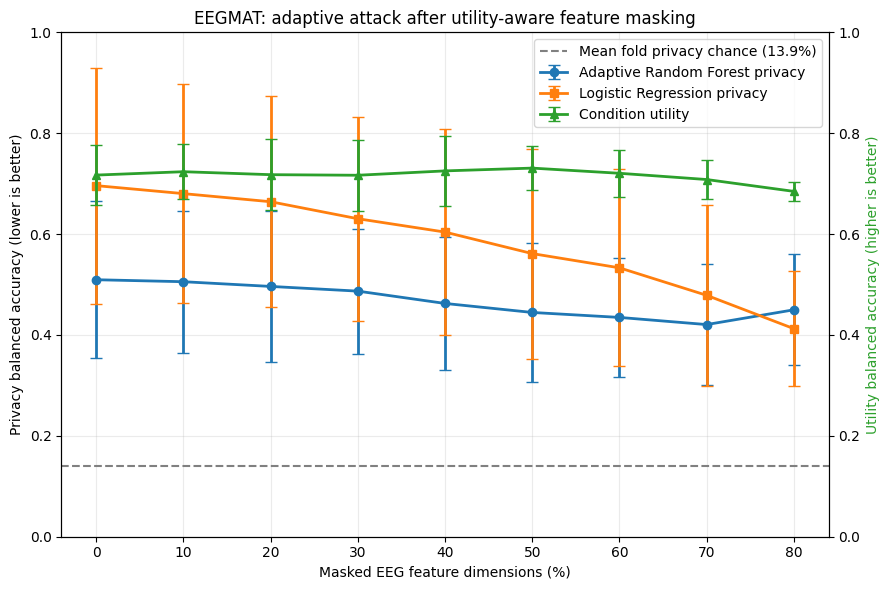

Saved direction-level results: /content/drive/MyDrive/URV_Datasets/eegmat/results/eegmat_adaptive_rf_privacy_detailed.csv
Saved independent fold summary: /content/drive/MyDrive/URV_Datasets/eegmat/results/eegmat_adaptive_rf_privacy_fold_summary.csv
Saved adaptive RF summary: /content/drive/MyDrive/URV_Datasets/eegmat/results/eegmat_adaptive_rf_privacy_summary.csv
Saved RF vs Logistic comparison: /content/drive/MyDrive/URV_Datasets/eegmat/results/eegmat_adaptive_rf_vs_logistic.csv
Saved corrected figure: /content/drive/MyDrive/URV_Datasets/eegmat/results/eegmat_adaptive_rf_vs_logistic.png
Saved run metadata: /content/drive/MyDrive/URV_Datasets/eegmat/results/eegmat_adaptive_rf_run.json


In [6]:
fig, ax1 = plt.subplots(figsize=(9, 6))

ax1.errorbar(
    comparison["mask_percentage"],
    comparison["privacy_ba_mean"],
    yerr=comparison["privacy_ba_ci95_half_width"],
    marker="o", capsize=4, linewidth=2,
    label="Adaptive Random Forest privacy",
)
ax1.errorbar(
    comparison["mask_percentage"],
    comparison["logistic_privacy_ba_mean"],
    yerr=comparison["logistic_privacy_ba_ci95_half_width"],
    marker="s", capsize=4, linewidth=2,
    label="Logistic Regression privacy",
)
mean_chance = float(fold_results["chance_accuracy"].mean())
ax1.axhline(
    mean_chance, color="gray", linestyle="--",
    label=f"Mean fold privacy chance ({mean_chance:.1%})",
)
ax1.set_xlabel("Masked EEG feature dimensions (%)")
ax1.set_ylabel("Privacy balanced accuracy (lower is better)")
ax1.set_ylim(0, 1)
ax1.grid(alpha=0.25)

ax2 = ax1.twinx()
ax2.errorbar(
    comparison["mask_percentage"],
    comparison["utility_ba_mean"],
    yerr=comparison["utility_ba_ci95_half_width"],
    color="tab:green", marker="^", capsize=4, linewidth=2,
    label="Condition utility",
)
ax2.set_ylabel("Utility balanced accuracy (higher is better)", color="tab:green")
ax2.set_ylim(0, 1)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="best")
plt.title("EEGMAT: adaptive attack after utility-aware feature masking")
plt.tight_layout()
plt.savefig(FIGURE_FILE, dpi=200, bbox_inches="tight")
plt.show()

run_metadata = {
    "dataset": "EEGMAT clean EEG-only 1-80 Hz",
    "released_representation": "utility-aware mean-masked EEG feature vector",
    "attacker": "adaptive RandomForestClassifier retrained per fold, mask, and direction",
    "rf_trees": RF_TREES,
    "outer_folds": len(splits),
    "privacy_directions": ["rest -> arithmetic", "arithmetic -> rest"],
    "uncertainty_unit": "five independent outer folds after averaging directions",
    "mask_selection_uses_outer_training_subjects_only": True,
    "mask_percentages": MASK_PERCENTAGES,
    "files": {
        "direction_detailed": str(DETAIL_FILE),
        "fold_summary": str(FOLD_FILE),
        "rf_summary": str(SUMMARY_FILE),
        "comparison": str(COMPARISON_FILE),
        "figure": str(FIGURE_FILE),
    },
}
with open(RUN_FILE, "w") as handle:
    json.dump(run_metadata, handle, indent=2)

print("Saved direction-level results:", DETAIL_FILE)
print("Saved independent fold summary:", FOLD_FILE)
print("Saved adaptive RF summary:", SUMMARY_FILE)
print("Saved RF vs Logistic comparison:", COMPARISON_FILE)
print("Saved corrected figure:", FIGURE_FILE)
print("Saved run metadata:", RUN_FILE)